DATASET = home_credit | USE_GPU = auto | ENCODE_CATEGORICALS = False
  DATASET (config): home_credit
  DATASET (in use): home_credit
  rows=16,000  features=104 (numeric=104, categorical=0)  default_rate=0.0819
  >> REAL dataset in use.
train: n=   9,600  default_rate=0.0820
es   : n=   3,200  default_rate=0.0819
eval : n=   3,200  default_rate=0.0819
MAX_FEATURES=25: kept top-25 features by |corr| -> ['EXT_SOURCE_3', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'DAYS_BIRTH', 'FLOORSMIN_AVG', 'REGION_RATING_CLIENT', 'REG_CITY_NOT_LIVE_CITY', 'REGION_RATING_CLIENT_W_CITY'] ...
final feature count: 25
WoE features: {'train': (9600, 25), 'es': (3200, 25), 'eval': (3200, 25)}
processed artifacts persisted


C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[saved] 00_monotonicity_check.png  &  00_monotonicity_check.pdf


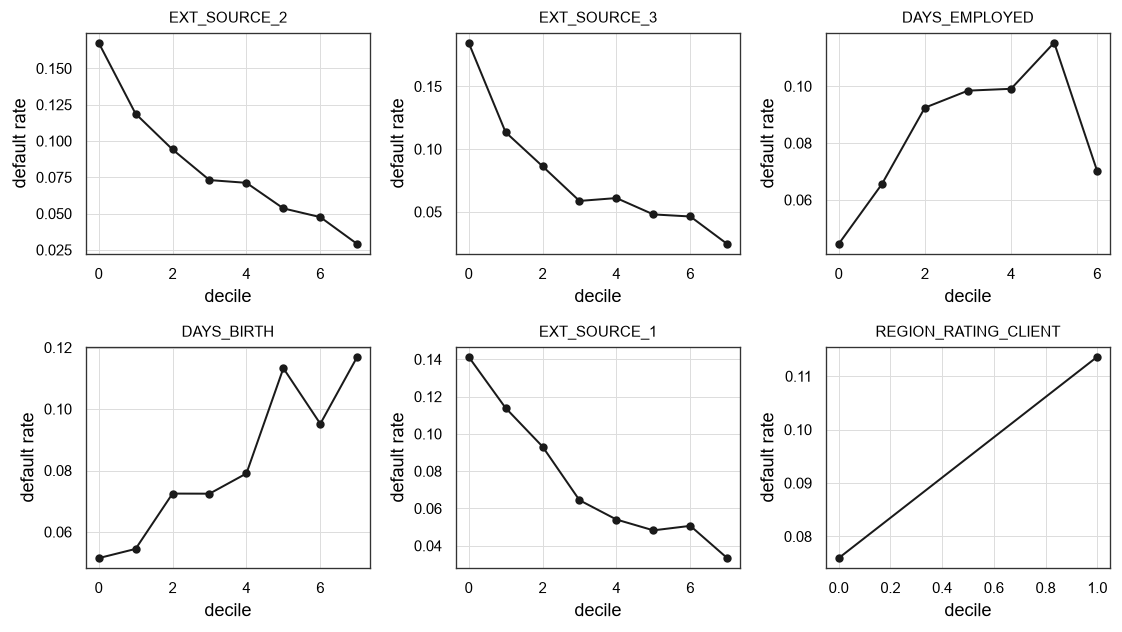

In [1]:
# Notebook 00 — Data Preparation & Triple Split

import json, pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import common as C
import config as CFG
import data_loaders as DL
C.set_grayscale_style()
RNG = np.random.default_rng(C.RANDOM_STATE)

SPLIT_FRACS = (0.60, 0.20, 0.20)   # train / es / eval
print("DATASET =", CFG.DATASET, "| USE_GPU =", CFG.USE_GPU,
      "| ENCODE_CATEGORICALS =", CFG.ENCODE_CATEGORICALS)


# ----------------------------------------------------------------------------
# Load (dispatch on config.DATASET)
# ----------------------------------------------------------------------------
X, y, source, mono_hint = DL.load_dataset()
cat_cols = [c for c in X.columns if str(X[c].dtype) == "category"]
num_cols = [c for c in X.columns if c not in cat_cols]

# --- LOUD preflight banner: confirm the REAL dataset is in use ----------------
is_fallback = (CFG.DATASET != "synthetic") and (source == "synthetic")
print("=" * 64)
print(f"  DATASET (config): {CFG.DATASET}")
print(f"  DATASET (in use): {source}")
print(f"  rows={len(X):,}  features={X.shape[1]} "
      f"(numeric={len(num_cols)}, categorical={len(cat_cols)})  "
      f"default_rate={y.mean():.4f}")
if source == "synthetic" and CFG.DATASET == "synthetic":
    print("  >> SYNTHETIC demo data (methodology check, not a real-data result).")
elif is_fallback:
    print("  >> WARNING: fell back to SYNTHETIC — this is NOT a real-data result!")
else:
    print("  >> REAL dataset in use.")
print("=" * 64)
assert not is_fallback, ("Fell back to synthetic despite DATASET="
                         f"{CFG.DATASET}. Check data/raw/ and config.py.")


# ----------------------------------------------------------------------------
# C2 triple split (stratified)
# ----------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
idx = np.arange(len(X))
tr_idx, tmp_idx = train_test_split(idx, train_size=SPLIT_FRACS[0], stratify=y,
                                   random_state=C.RANDOM_STATE)
es_rel = SPLIT_FRACS[1] / (SPLIT_FRACS[1] + SPLIT_FRACS[2])
es_idx, ev_idx = train_test_split(tmp_idx, train_size=es_rel,
                                  stratify=y[tmp_idx], random_state=C.RANDOM_STATE)
splits = {"train": tr_idx, "es": es_idx, "eval": ev_idx}
for k, v in splits.items():
    print(f"{k:5s}: n={len(v):>8,}  default_rate={y[v].mean():.4f}")


# ----------------------------------------------------------------------------
# Categorical encoding (target encoding fit on TRAIN only), if enabled
# ----------------------------------------------------------------------------
if cat_cols:
    maps = DL.fit_target_encoding(X.iloc[tr_idx], y[tr_idx], cat_cols)
    X = DL.apply_target_encoding(X, maps)
    print("target-encoded categoricals:", cat_cols)
X = X.astype(float)
FEATURES = list(X.columns)

# optional MAX_FEATURES cap: keep top-K by |corr(feature, y)| on train (nan-safe)
K = getattr(CFG, "MAX_FEATURES", None)
if K is not None and K < len(FEATURES):
    ytr_ = y[tr_idx]
    strength = {}
    for f in FEATURES:
        v = X[f].to_numpy()[tr_idx]; ok = ~np.isnan(v)
        strength[f] = abs(np.corrcoef(v[ok], ytr_[ok])[0, 1]) if ok.sum() > 2 else 0.0
    FEATURES = [f for f, _ in sorted(strength.items(), key=lambda kv: -kv[1])][:K]
    X = X[FEATURES]
    print(f"MAX_FEATURES={K}: kept top-{K} features by |corr| ->", FEATURES[:8], "...")
print("final feature count:", len(FEATURES))


# ----------------------------------------------------------------------------
# WoE-transformed features (fit bins & WoE on TRAIN only) + data-driven monotone
# ----------------------------------------------------------------------------
Xtr = X.iloc[tr_idx]
woe_edges, woe_maps, mono = {}, {}, {}
for f in FEATURES:
    edges = C.quantile_edges(Xtr[f].to_numpy(), n_bins=8)
    _, wmap = C.woe_transform(Xtr[f].to_numpy(), y[tr_idx], edges)
    woe_edges[f], woe_maps[f] = edges, wmap

def apply_woe(frame):
    out = np.zeros((len(frame), len(FEATURES)))
    for j, f in enumerate(FEATURES):
        v = frame[f].to_numpy()
        idx = np.digitize(np.where(np.isnan(v), -np.inf, v), woe_edges[f], right=False)
        out[:, j] = np.array([woe_maps[f].get(int(b), 0.0) for b in idx])
    return out

Xwoe = {name: apply_woe(X.iloc[ix]) for name, ix in splits.items()}

# monotone direction: sign of corr(WoE_feature, y) on train (WoE is risk-oriented)
for j, f in enumerate(FEATURES):
    c = np.corrcoef(Xwoe["train"][:, j], y[tr_idx])[0, 1]
    mono[f] = int(np.sign(c)) if np.isfinite(c) else 0
if mono_hint:                      # prefer explicit hint when the loader gave one
    mono.update({k: v for k, v in mono_hint.items() if k in mono})
print("WoE features:", {k: v.shape for k, v in Xwoe.items()})


# ----------------------------------------------------------------------------
# Persist everything downstream notebooks need
# ----------------------------------------------------------------------------
X.to_pickle(C.PROC_DIR / "X_all.pkl")
np.save(C.PROC_DIR / "y_all.npy", y)
with open(C.PROC_DIR / "splits.pkl", "wb") as fh:
    pickle.dump(splits, fh)
with open(C.PROC_DIR / "woe.pkl", "wb") as fh:
    pickle.dump({"edges": woe_edges, "maps": woe_maps, "Xwoe": Xwoe}, fh)
meta = {"source": source, "n": int(len(X)), "features": FEATURES,
        "monotone_default": mono, "default_rate": float(y.mean()),
        "split_sizes": {k: int(len(v)) for k, v in splits.items()}}
with open(C.PROC_DIR / "meta.json", "w") as fh:
    json.dump(meta, fh, indent=2)
print("processed artifacts persisted")


# ----------------------------------------------------------------------------
# Figure: default rate by decile for the 6 strongest features (monotonicity)
# ----------------------------------------------------------------------------
strength = {f: abs(np.corrcoef(Xwoe["train"][:, j], y[tr_idx])[0, 1])
            for j, f in enumerate(FEATURES)}
show = [f for f, _ in sorted(strength.items(), key=lambda kv: -kv[1])][:6]
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.4), sharey=False)
for ax, f in zip(axes.ravel(), show):
    v = X[f].to_numpy(); ok = ~np.isnan(v)
    try:
        q = pd.qcut(pd.Series(v[ok]), 8, duplicates="drop")
        rate = pd.Series(y[ok]).groupby(q, observed=True).mean()
        ax.plot(range(len(rate)), rate.to_numpy(), marker="o", color="#1a1a1a",
                markersize=4, linewidth=1.2)
    except Exception:
        ax.text(0.5, 0.5, "n/a", ha="center")
    ax.set_title(f, fontsize=9); ax.set_xlabel("decile"); ax.set_ylabel("default rate")
fig.tight_layout()
C.save_fig(fig, "00_monotonicity_check")
plt.show()

In [2]:
# regen_fig_00_01.py  — run from the notebooks/ folder
import json, pickle
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import common as C
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
woe = pickle.load(open(C.PROC_DIR / "woe.pkl", "rb"))
FEATURES = json.load(open(C.PROC_DIR / "meta.json"))["features"]
tr = SP["train"]

# ---- Fig 00: default rate by decile for the 6 strongest features ----
strength = {f: abs(np.corrcoef(woe["Xwoe"]["train"][:, j], y[tr])[0, 1])
            for j, f in enumerate(FEATURES)}
show = [f for f, _ in sorted(strength.items(), key=lambda kv: -kv[1])][:6]
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.4))
for ax, f in zip(axes.ravel(), show):
    v = X[f].to_numpy(); ok = ~np.isnan(v)
    try:
        q = pd.qcut(pd.Series(v[ok]), 8, duplicates="drop")
        rate = pd.Series(y[ok]).groupby(q, observed=True).mean()
        ax.plot(range(len(rate)), rate.to_numpy(), marker="o", color="#1a1a1a",
                markersize=4, linewidth=1.2)
    except Exception:
        ax.text(0.5, 0.5, "n/a", ha="center")
    ax.set_title(f, fontsize=9); ax.set_xlabel("decile"); ax.set_ylabel("default rate")
fig.tight_layout()
C.save_fig(fig, "00_monotonicity_check"); plt.close(fig)

# ---- Fig 01: teacher reliability diagram (eval fold) ----
pT = np.load(C.PROC_DIR / "teacher_probs.npz")["eval"]
yv = y[SP["eval"]]
ids = C._bin_ids(pT, 10, "quantile")
xs = np.array([pT[ids == b].mean() for b in np.unique(ids)])
ys = np.array([yv[ids == b].mean() for b in np.unique(ids)])
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot([0, 1], [0, 1], color="#999999", lw=1.0, ls="--")
ax.plot(xs, ys, marker="o", color="#1a1a1a", lw=1.3, markersize=5)
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed default frequency")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
fig.tight_layout()
C.save_fig(fig, "01_teacher_reliability"); plt.close(fig)
print("regenerated 00 and 01 (png + pdf) in results/figures/")

C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[saved] 00_monotonicity_check.png  &  00_monotonicity_check.pdf
[saved] 01_teacher_reliability.png  &  01_teacher_reliability.pdf
regenerated 00 and 01 (png + pdf) in results/figures/
